In [25]:
from google.colab import files
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import numpy as np

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [13]:
upload=files.upload()
filename = next(iter(upload))
df = pd.read_csv(filename)

Saving temperatures.csv to temperatures (1).csv


,YEAR,JAN,FEB,MAR,APR,MAY,JUN,JUL,AUG,SEP,OCT,NOV,DEC,ANNUAL,JAN-FEB,MAR-MAY,JUN-SEP,OCT-DEC
0,1901,22.40,24.14,29.07,31.91,33.41,33.18,31.21,30.39,30.47,29.97,27.31,24.49,28.96,23.27,31.46,31.27,27.25
1,1902,24.93,26.58,29.77,31.78,33.73,32.91,30.92,30.73,29.80,29.12,26.31,24.04,29.22,25.75,31.76,31.09,26.49
2,1903,23.44,25.03,27.83,31.39,32.91,33.00,31.34,29.98,29.85,29.04,26.08,23.65,28.47,24.24,30.71,30.92,26.26
3,1904,22.50,24.73,28.21,32.02,32.64,32.07,30.36,30.09,30.04,29.20,26.36,23.63,28.49,23.62,30.95,30.66,26.40
4,1905,22.00,22.83,26.68,30.01,33.32,33.25,31.44,30.68,30.12,30.67,27.52,23.82,28.30,22.25,30.00,31.33,26.57


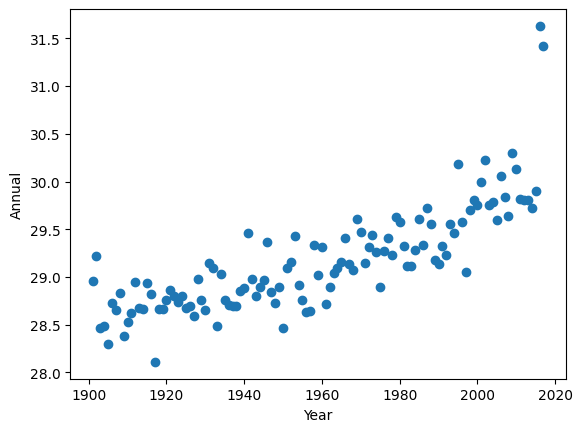

In [68]:
x=df["YEAR"]
y=df["ANNUAL"]
plt.xlabel("Year")
plt.ylabel("Annual")
plt.scatter(x,y)
plt.show()

In [26]:
x=np.array(x).reshape(-1,1)
y=np.array(y).reshape(-1,1)
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2)


In [62]:
from sklearn.linear_model import LinearRegression
model1=LinearRegression()
model1.fit(x_train,y_train)
pred1=model1.predict(x_test)
merged=np.concatenate((pred1,y_test),axis=1)
merged

array([[29.38647371, 29.41      ],
       [29.88422436, 31.63      ],
       [28.42926093, 29.22      ],
       [29.57791627, 29.23      ],
       [29.47581357, 29.28      ],
       [29.51410208, 29.72      ],
       [29.87146152, 29.9       ],
       [28.79938321, 29.15      ],
       [28.7610947 , 28.98      ],
       [28.97806293, 28.97      ],
       [28.91424874, 28.88      ],
       [29.82041017, 29.82      ],
       [29.68001897, 29.75      ],
       [29.62896762, 29.58      ],
       [29.09292846, 28.92      ],
       [28.44202377, 28.47      ],
       [29.70554464, 30.23      ],
       [28.88872307, 28.7       ],
       [29.85869869, 29.72      ],
       [28.46754944, 28.3       ],
       [28.49307512, 28.65      ],
       [29.25884534, 29.14      ],
       [29.73107031, 29.79      ],
       [28.658992  , 28.76      ]])

In [59]:
from sklearn.metrics import r2_score
r2 = r2_score(y_test, pred1)
print(f"R² za model1: {r2}")

R²: 0.5957481334020757


In [63]:
from sklearn.metrics import mean_squared_error
mse1 = mean_squared_error(y_test, pred1)
print(f"MSE za model1: {mse1}")

MSE za model1: 0.1873595109496212


In [55]:
from sklearn.preprocessing import PolynomialFeatures
poly=PolynomialFeatures(degree=2)
x_poly_train=poly.fit_transform(x_train)
model2=LinearRegression()
model2.fit(x_poly_train,y_train)
x_poly_test=poly.transform(x_test)
pred2=model2.predict(x_poly_test)

In [66]:
mse2=mean_squared_error(pred2,y_test)
print("mse2 je za model2: {}".format(mse2))

mse2 je za model2: 0.1454273742990798


In [64]:
r2 = r2_score(y_test, pred2)
print(f"R² za model2: {r2}")

R² za model2: 0.6862220272839751


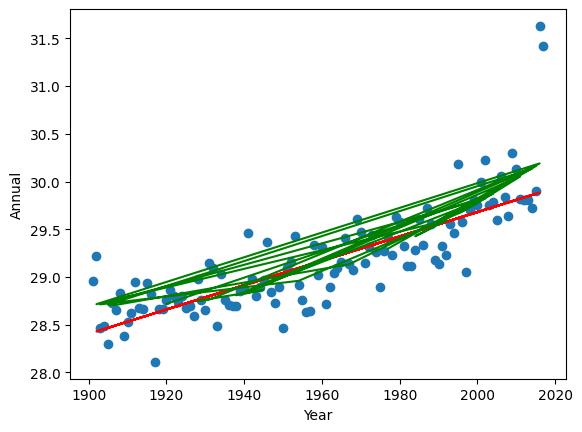

In [67]:
plt.plot(x_test,pred1,"r")
plt.plot(x_test,pred2,"g")
x=df["YEAR"]
y=df["ANNUAL"]
plt.xlabel("Year")
plt.ylabel("Annual")
plt.scatter(x,y)
plt.show()